# Does the block field still win without the wall?

The constrained study on these two tables put a hard ball $K_r=\{\|w\|_2\le r\}$ around the
posterior and compared three drifts: no skew, the constant $J_a$, and the block-diagonal
state-dependent $J_s(x)$. Under that constraint $J_s(x)$ wins, and the reason is structural
rather than tuned: each $3\times3$ cross-product block annihilates its own sub-vector, so
$J_s(x)x=0$ and the skew drift is automatically tangent to $\partial K$. The constant $J_a$
has no such property, drives walkers into the wall, and is not even admissible there.

This notebook runs the same experiment under the **unconstrained** dynamics,

$$dX_t=-a(X_t)\bigl(I+J(X_t)\bigr)\nabla U_0(X_t)\,dt+\sqrt{2a(X_t)}\,dW_t,
\qquad a=e^{U-U_0},$$

which is the canonical stream choice $\psi=e^{-U_0}$. There is no projection and no
reflection, so the boundary condition $J(x)n(x)=0$ has nothing to act on. The only surviving
requirement is that $J$ be skew-symmetric with $\nabla\cdot J=0$, which **both** fields
satisfy. So $J_a$ becomes admissible, and the property that earned $J_s$ its win becomes
free of charge.

The theory already warns what happens next. The remark that introduces the block
construction notes that it *"annihilates a radial $\nabla U_0$; the constant-$J$ Student
construction and the more general stream choice therefore remain essential."* This notebook
measures how much that costs on real data.

In [1]:
%matplotlib inline
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

torch.set_default_dtype(torch.float64)
os.makedirs("figures", exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

import sys
sys.path.insert(0, os.path.abspath(".."))
from ands import data as D
from ands import logistic as L
from ands import skew as S
from ands.diagnostics import w1_per_coord

CACHE = os.path.abspath(os.path.join("..", "results"))
os.makedirs(CACHE, exist_ok=True)

# The potential's shape.  tau sets how sharp the posterior is; lam is the
# non-differentiable L1 charge that makes the anchoring non-vacuous; kappa is the
# Gaussian prior that replaces the hard wall; mu is the smoothing bandwidth.
CFG = dict(tau=300.0, lam=0.5, kappa=0.5, mu=0.05)

# The paper's implementation parameters, carried over unchanged.
RUN = dict(eta=1e-4, batch=30, n_walkers=100, track_every=10)
REPLICAS = 5
REF = dict(n_chains=600, n_steps=8000)

# Per dataset: iteration budget and the paper's own field strengths.
SETUP = {
    "Telescope": dict(load=D.load_magic_d9,   steps=1000, a=2.0, s=[5.0, 5.0, 5.0]),
    "Titanic":   dict(load=D.load_titanic_d9, steps=1500, a=3.0, s=[2.0, 7.0, 2.0]),
}
CFG

{'tau': 300.0, 'lam': 0.5, 'kappa': 0.5, 'mu': 0.05}

## The two tables, at $d=9$

The block field is built from $3\times3$ blocks, so it needs a dimension divisible by three.
Both tables are cut to exactly nine features, which is also the dimension the constrained
study quotes. The intercept is dropped (the columns are centred) and, for the Telescope
data, `fConc1` goes: it correlates with `fConc` at about $0.98$, so it is the cheapest of
the ten to lose.

The split is the paper's 80/20, stratified. Standardisation is recomputed on the training
rows alone, so no test statistic leaks into the fit.

In [2]:
DATA, rows = {}, []
for k, cf in SETUP.items():
    ds = cf["load"]()
    tr, te = D.train_test_split(ds, test_frac=0.2, seed=0)
    t = L.UnconstrainedLogisticTarget(tr, **CFG)
    DATA[k] = dict(train=tr, test=te, target=t, Pte=t.eval_matrix(te))
    rows.append({"dataset": k, "n": ds.n, "d": ds.d, "train": tr.n, "test": te.n,
                 "P(y=+1)": round(float((ds.y > 0).mean()), 3),
                 "steps": cf["steps"], "eta": RUN["eta"], "batch": RUN["batch"]})
pd.DataFrame(rows).set_index("dataset")

,n,d,train,test,P(y=+1),steps,eta,batch
dataset,,,,,,,,
Telescope,19020,9,15216,3804,0.648,1000,0.0001,30
Titanic,891,9,713,178,0.384,1500,0.0001,30


## The two fields, and what separates them

Both are skew-symmetric with $\nabla\cdot J=0$, so both are admissible for the unconstrained
dynamics and neither needs a divergence correction. The table below checks that numerically,
against autograd rather than against the closed form it is meant to verify. These are
pointwise identities in $x$, so they hold at any draw and do not depend on the dataset.

The last column is the point. A real skew matrix in odd dimension is always singular, so
$J_a$ carries a one-dimensional kernel it cannot rotate. The block field carries a
**three**-dimensional one, spanned by $(x_{1:3},0,0)$, $(0,x_{4:6},0)$ and $(0,0,x_{7:9})$,
because each block annihilates its own sub-vector. On a centred ball that kernel is exactly
what buys tangency at the wall. Here there is no wall.

In [3]:
def field_report(f, w, g):
    M = torch.stack([f.matrix(w[i]) for i in range(len(w))])
    sv = torch.linalg.svdvals(M)
    tol = 1e-10 * sv.max(dim=1, keepdim=True).values
    return dict(antisymmetry=float((M + M.transpose(1, 2)).abs().max()),
                div_closed=float(f.divergence(w).abs().max()),
                div_autograd=float(S.autograd_divergence(f, w).abs().max()),
                max_Jx=float(f.apply(w, w).abs().max()),
                dim_ker=float((sv < tol).sum(dim=1).to(torch.float64).mean()))


def annihilated_share(f, w, g):
    # fraction of ||grad U_0||^2 lying in ker J(w) -- the part the field cannot rotate
    out = []
    for i in range(len(w)):
        M = f.matrix(w[i])
        _, s_i, Vh = torch.linalg.svd(M)
        null = Vh[s_i < 1e-10 * s_i.max()]
        out.append(float(((null @ g[i]) ** 2).sum() / (g[i] @ g[i])))
    return float(np.mean(out))


FIELDS = {"$J_a$": S.ConstantSkew(9, 1.0, normalise=False),
          "$J_s(x)$": S.BlockCrossSkew(9, 1.0)}

_w = L.uniform_ball(200, 9, 2.0, generator=torch.Generator().manual_seed(0))
_, _g = DATA["Titanic"]["target"].anchored(_w)
REP = pd.DataFrame([dict(field=lab.replace("$", ""), **field_report(f, _w, _g))
                    for lab, f in FIELDS.items()]).set_index("field")
print("both fields are skew-symmetric and divergence-free, so both are admissible here;")
print("only the block field annihilates x, and it gives up three directions to do it.\n")
REP.round(12)

both fields are skew-symmetric and divergence-free, so both are admissible here;
only the block field annihilates x, and it gives up three directions to do it.



,antisymmetry,div_closed,div_autograd,max_Jx,dim_ker
field,,,,,
J_a,0.0,0.0,0.0,2.477947,1.0
J_s(x),0.0,0.0,0.0,0.000000,3.0


## Protocol

Straight from the constrained experiments: step size $\eta=10^{-4}$, minibatch $m=30$, $100$
walkers started uniform on the centred unit ball, $1000$ iterations for the Telescope data
and $1500$ for Titanic. Accuracy is reported over the training and the test split, as mean
and standard deviation across walkers.

Accuracy alone cannot settle this. It reads only the sign of $\langle w,\phi\rangle$, so it
is invariant under $w\mapsto cw$ and nearly blind to the sampling bias that separates these
schemes. Every run therefore also gets scored by $W_1$ against a random-walk Metropolis
reference on the exact $U$, drawn fresh on both sides so the floor is what two converged
samples of this size cost each other.

In [4]:
def reference(k, seed):
    # RWM on the exact U -- cached, since the Telescope chain is the expensive part.
    f = os.path.join(CACHE, "nald_ref_{}_{}.npy".format(k, seed))
    if os.path.exists(f):
        return np.load(f)
    t0 = time.time()
    w, rate = L.run_rwm(DATA[k]["target"], seed=seed, **REF)
    np.save(f, w.numpy())
    print("   {:<10} reference seed {}: acceptance {:.2f}, {:.0f}s".format(
        k, seed, rate, time.time() - t0), flush=True)
    return w.numpy()


def reach(it, curve, thr):
    ok = curve >= thr
    return float(it[np.argmax(ok)]) if ok.any() else np.nan


def boot(v, B=4000, seed=0):
    v = np.asarray(v, float)
    if not np.any(np.isfinite(v)):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    dr = [np.nanmean(x) for x in (v[rng.integers(0, len(v), len(v))] for _ in range(B))
          if np.any(np.isfinite(x))]
    return np.nanmean(v), float(np.percentile(dr, 2.5)), float(np.percentile(dr, 97.5))


def boot_ratio(base, cur, B=4000, seed=1):
    base, cur = np.asarray(base, float), np.asarray(cur, float)
    if not (np.any(np.isfinite(base)) and np.any(np.isfinite(cur))):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    dr = []
    for _ in range(B):
        p = base[rng.integers(0, len(base), len(base))]
        q = cur[rng.integers(0, len(cur), len(cur))]
        if np.any(np.isfinite(p)) and np.any(np.isfinite(q)):
            dr.append(np.nanmean(p) / np.nanmean(q))
    return np.nanmean(base) / np.nanmean(cur), float(np.percentile(dr, 2.5)), \
           float(np.percentile(dr, 97.5))


def run_scheme(k, field, reps=REPLICAS):
    # Replicas of one scheme; returns iterations, per-walker accuracy, final ensembles.
    d = DATA[k]
    out = [L.run_nald(d["target"], field, n_steps=SETUP[k]["steps"],
                      eval_sets=(d["target"].Psi, d["Pte"]), seed=100 + r, **RUN)
           for r in range(reps)]
    it = out[0][0]
    tr = np.concatenate([o[1][0] for o in out], axis=1)     # (T, reps*walkers)
    te = np.concatenate([o[1][1] for o in out], axis=1)
    return it, tr, te, [o[2].numpy() for o in out]


print("building references (cached under results/)")
CEIL, FLOOR = {}, {}
for k in SETUP:
    ra, rb = reference(k, 1), reference(k, 7)
    t = DATA[k]["target"]
    CEIL[k] = dict(train=float(t.accuracy(torch.tensor(ra)).mean()),
                   test=float(t.accuracy(torch.tensor(ra), DATA[k]["Pte"]).mean()))
    FLOOR[k] = float(w1_per_coord(ra, rb).mean())
    DATA[k]["ref"] = ra
    print("   {:<10} ceiling train {:.4f} test {:.4f}   W1 floor {:.4f}".format(
        k, CEIL[k]["train"], CEIL[k]["test"], FLOOR[k]), flush=True)

building references (cached under results/)


   Telescope  ceiling train 0.7772 test 0.7848   W1 floor 0.0190


   Titanic    ceiling train 0.7719 test 0.7781   W1 floor 0.0149


## The paper's own settings

Three schemes at the strengths the constrained study used: $J_a$ with $a=2$ on the Telescope
data and $a=3$ on Titanic, $J_s(x)$ with $s=[5,5,5]$ and $s=[2,7,2]$.

In [5]:
COLORS = {"$J = 0$": "#C44E52", "$J_a$": "#4C72B0", "$J_s(x)$": "#DD8452"}
STYLE = {"$J = 0$": (0, (5, 2)), "$J_a$": "-", "$J_s(x)$": "-"}

CURVES, ENS = {}, {}
for k, cf in SETUP.items():
    grid = [("$J = 0$", S.ZeroSkew(9)),
            ("$J_a$", S.ConstantSkew(9, cf["a"], normalise=False)),
            ("$J_s(x)$", S.BlockCrossSkew(9, cf["s"]))]
    for lab, f in grid:
        t0 = time.time()
        it, tr, te, ws = run_scheme(k, f)
        CURVES[(k, lab)] = (it, tr, te)
        ENS[(k, lab)] = ws
        print("   {:<10} {:<9} final train {:.4f} test {:.4f}   {:4.0f}s".format(
            k, lab.replace("$", ""), tr[-1].mean(), te[-1].mean(), time.time() - t0), flush=True)

   Telescope  J = 0     final train 0.7759 test 0.7810      9s


   Telescope  J_a       final train 0.7783 test 0.7835      9s


   Telescope  J_s(x)    final train 0.7743 test 0.7791      9s


   Titanic    J = 0     final train 0.7721 test 0.7834      5s


   Titanic    J_a       final train 0.7706 test 0.7812      5s


   Titanic    J_s(x)    final train 0.7728 test 0.7777      5s


In [6]:
# cache the curves and the final ensembles, so every figure below can be redrawn
# without paying for the reference chains again
np.savez_compressed(os.path.join(CACHE, "nald_curves.npz"),
                    **{"{}|{}|{}".format(k, lab, w): v
                       for (k, lab), trio in CURVES.items()
                       for w, v in (("it", trio[0]), ("train", trio[1]), ("test", trio[2]))},
                    **{"ens|{}|{}".format(k, lab): np.stack(v) for (k, lab), v in ENS.items()},
                    **{"ceil|{}|{}".format(k, w): np.array(CEIL[k][w])
                       for k in SETUP for w in ("train", "test")},
                    **{"floor|{}".format(k): np.array(FLOOR[k]) for k in SETUP})
print("cached", len(CURVES), "curves")

cached 6 curves


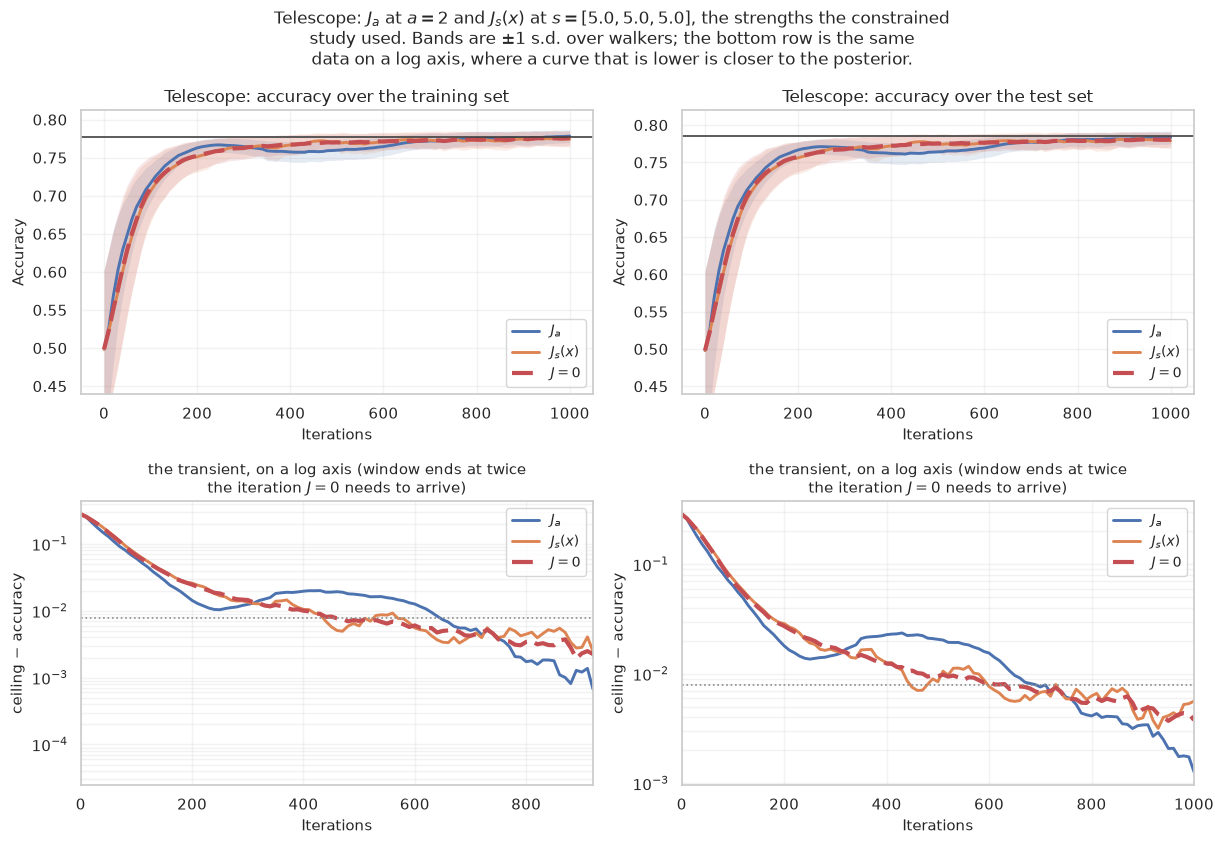

In [7]:
ORDER = ["$J_a$", "$J_s(x)$", "$J = 0$"]      # J = 0 last, so it is never hidden
WIDTH = {"$J = 0$": 3.0, "$J_a$": 2.1, "$J_s(x)$": 2.1}


def paper_figure(k, fname):
    cf = SETUP[k]
    fig, axes = plt.subplots(2, 2, figsize=(12.4, 8.6))
    for c, (split, ttl) in enumerate(((1, "training set"), (2, "test set"))):
        ceil = CEIL[k]["train" if split == 1 else "test"]
        top, bot = axes[0, c], axes[1, c]
        for lab in ORDER:
            it, tr, te = CURVES[(k, lab)]
            a = tr if split == 1 else te
            m, sd = a.mean(axis=1), a.std(axis=1)
            top.plot(it, m, color=COLORS[lab], linestyle=STYLE[lab],
                     linewidth=WIDTH[lab], label=lab)
            top.fill_between(it, m - sd, m + sd, color=COLORS[lab], alpha=0.14, linewidth=0)
            gap = ceil - m
            ok = gap > 0
            bot.plot(it[ok], gap[ok], color=COLORS[lab], linestyle=STYLE[lab],
                     linewidth=WIDTH[lab], label=lab)
        top.axhline(ceil, color="0.25", linewidth=1.2)
        top.set_ylim(0.44, ceil + 0.035)
        top.set_title("{}: accuracy over the {}".format(k, ttl), fontsize=12)
        top.set_ylabel("Accuracy", fontsize=11)
        bot.axhline(0.01 * ceil, color="0.55", linestyle=":", linewidth=1.2)
        bot.set_yscale("log")
        # past the point where J = 0 itself arrives, the gap is fluctuation rather than
        # transient, so the window stops there; that is also where the speed claim lives
        it0, tr0, te0 = CURVES[(k, "$J = 0$")]
        arrive = reach(it0, (tr0 if split == 1 else te0).mean(axis=1), 0.99 * ceil)
        bot.set_xlim(0, min(cf["steps"], 2.0 * arrive) if np.isfinite(arrive) else cf["steps"])
        bot.set_title("the transient, on a log axis (window ends at twice\n"
                      "the iteration $J = 0$ needs to arrive)", fontsize=11)
        bot.set_ylabel("ceiling $-$ accuracy", fontsize=11)
        for ax in (top, bot):
            ax.set_xlabel("Iterations", fontsize=11)
            ax.legend(fontsize=10, loc="lower right" if ax is top else "upper right")
            ax.grid(alpha=0.25, which="both")
    fig.suptitle("{}: $J_a$ at $a={:g}$ and $J_s(x)$ at $s={}$, the strengths the constrained\n"
                 "study used. Bands are $\\pm1$ s.d. over walkers; the bottom row is the same\n"
                 "data on a log axis, where a curve that is lower is closer to the posterior."
                 .format(k, cf["a"], cf["s"]), fontsize=12)
    plt.tight_layout()
    plt.savefig("figures/{}.pdf".format(fname), dpi=300, bbox_inches="tight")
    plt.show()


paper_figure("Telescope", "nald_telescope")

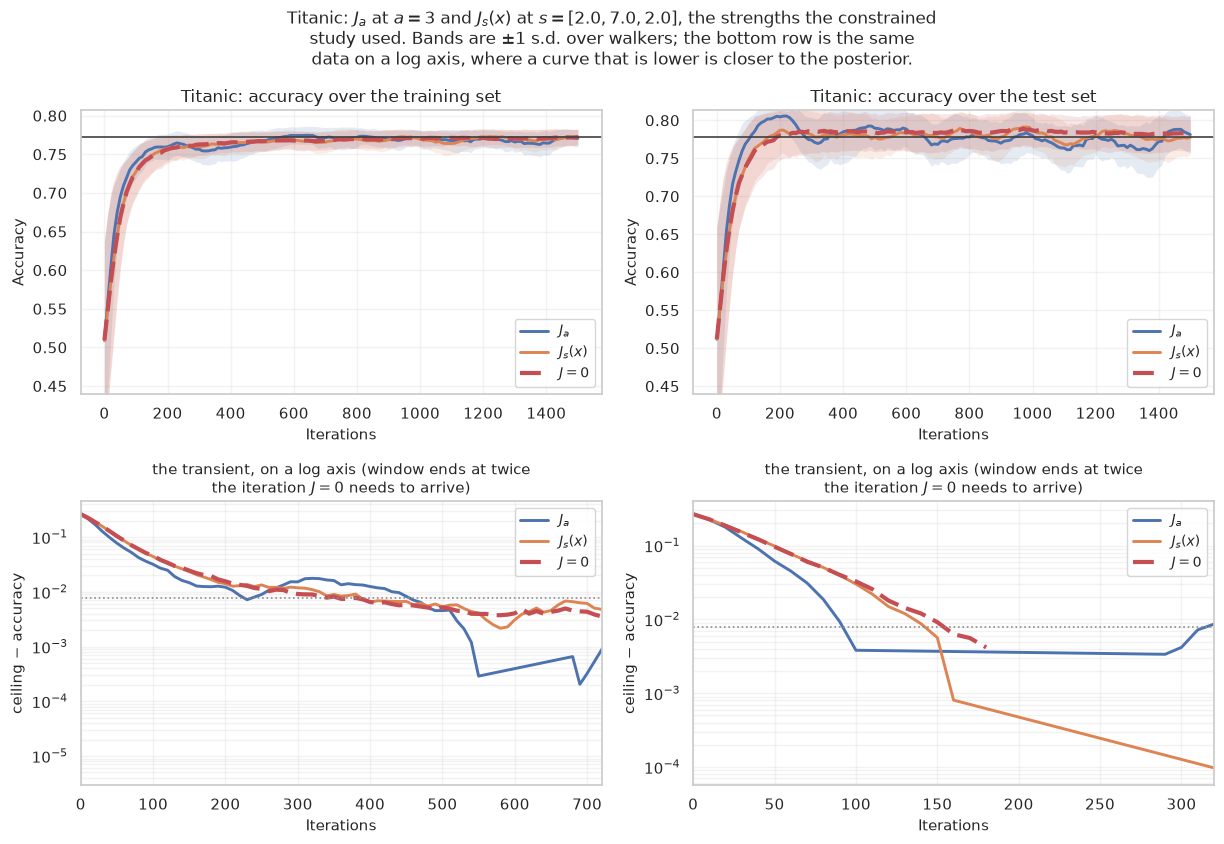

In [8]:
paper_figure("Titanic", "nald_titanic")

## Sweeping the strength

The settings above were chosen for a problem with a wall. Neither field should be judged at
a strength picked for different dynamics, so both get swept. Two numbers per setting:
iterations for the mean training accuracy to reach 99% of the exact posterior's, and $W_1$
to the reference at the end of the run, in units of the floor.

In [9]:
GRID_A = [0.5, 1.0, 2.0, 3.0, 5.0]
GRID_S = [1.0, 2.0, 5.0, 10.0]

rows, SW = [], {}
for k in SETUP:
    ref, c = DATA[k]["ref"], CEIL[k]["train"]
    base = None
    grid = ([("$J = 0$", 0.0, S.ZeroSkew(9))]
            + [("$J_a$", a, S.ConstantSkew(9, a, normalise=False)) for a in GRID_A]
            + [("$J_s(x)$", s, S.BlockCrossSkew(9, s)) for s in GRID_S])
    for lab, strength, f in grid:
        it, tr, te, ws = run_scheme(k, f)
        per = [tr[:, i * RUN["n_walkers"]:(i + 1) * RUN["n_walkers"]].mean(axis=1)
               for i in range(REPLICAS)]
        r99 = [reach(it, p, 0.99 * c) for p in per]
        w1 = [float(w1_per_coord(ref, e).mean()) for e in ws]
        if lab == "$J = 0$":
            base = r99
        SW[(k, lab, strength)] = (np.mean(w1), r99)
        rows.append({"dataset": k, "field": lab.replace("$", ""), "strength": strength,
                     "iters to 99%": "{:.0f} [{:.0f}, {:.0f}]".format(*boot(r99)),
                     "_sp": np.nan if lab == "$J = 0$" else boot_ratio(base, r99)[0],
                     "speed-up": ("--" if lab == "$J = 0$"
                                  else "{:.2f}x [{:.2f}, {:.2f}]".format(*boot_ratio(base, r99))),
                     "W1": round(float(np.mean(w1)), 4),
                     "W1 / floor": round(float(np.mean(w1)) / FLOOR[k], 1),
                     "final test": round(float(te[-1].mean()), 4)})
        print("   {:<10} {:<9} s={:<5g} {}".format(k, lab.replace("$", ""), strength,
                                                   rows[-1]["iters to 99%"]), flush=True)
SWEEP = pd.DataFrame(rows)
SWEEP.set_index(["dataset", "field", "strength"]).drop(columns=["_sp"])

   Telescope  J = 0     s=0     450 [424, 470]


   Telescope  J_a       s=0.5   488 [480, 496]


   Telescope  J_a       s=1     398 [362, 426]


   Telescope  J_a       s=2     650 [626, 674]


   Telescope  J_a       s=3     538 [510, 580]


...

   Titanic    J_s(x)    s=1     370 [328, 406]


   Titanic    J_s(x)    s=2     376 [354, 398]


   Titanic    J_s(x)    s=5     322 [280, 362]


   Titanic    J_s(x)    s=10    396 [334, 458]


iters to 99%            speed-up      W1  \
dataset   field  strength                                               
Telescope J = 0  0.0       450 [424, 470]                  --  0.1760   
          J_a    0.5       488 [480, 496]  0.92x [0.87, 0.97]  0.1612   
                 1.0       398 [362, 426]  1.13x [1.03, 1.26]  0.1394   
                 2.0       650 [626, 674]  0.69x [0.65, 0.74]  0.1016   
                 3.0       538 [510, 580]  0.84x [0.76, 0.90]  0.0882   
                 5.0       410 [392, 436]  1.10x [1.01, 1.18]  0.1301   
          J_s(x) 1.0       440 [426, 456]  1.02x [0.96, 1.08]  0.1697   
                 2.0       426 [408, 444]  1.06x [0.98, 1.13]  0.1656   
                 5.0       434 [408, 462]  1.04x [0.95, 1.12]  0.1732   
                 10.0      522 [400, 683]  0.86x [0.65, 1.14]  0.2114   
Titanic   J = 0  0.0       362 [336, 390]                  --  0.0566   
          J_a    0.5       256 [238, 274]  1.41x [1.27, 1.57]  0.0592   
                 1.0       230 [218, 242]  1.57x [1.44, 1.72]  0.0571   
                 2.0       198 [182, 216]  1.83x [1.62, 2.04]  0.0630   
                 3.0       248 [188, 322]  1.46x [1.10, 1.97]  0.0806   
                 5.0       364 [330, 408]  0.99x [0.86, 1.14]  0.1277   
          J_s(x) 1.0       370 [328, 406]  0.98x [0.86, 1.13]  0.0521   
                 2.0       376 [354, 398]  0.96x [0.87, 1.06]  0.0585   
                 5.0       322 [280, 362]  1.12x [0.98, 1.32]  0.0777   
                 10.0      396 [334, 458]  0.91x [0.77, 1.11]  0.2437   

                           W1 / floor  final test  
dataset   field  strength                          
Telescope J = 0  0.0              9.3      0.7810  
          J_a    0.5              8.5      0.7805  
                 1.0              7.3      0.7804  
                 2.0              5.3      0.7835  
                 3.0              4.6      0.7841  
                 5.0              6.8      0.7824  
          J_s(x) 1.0              8.9      0.7825  
                 2.0              8.7      0.7834  
                 5.0              9.1      0.7791  
                 10.0            11.1      0.7704  
Titanic   J = 0  0.0              3.8      0.7834  
          J_a    0.5              4.0      0.7847  
                 1.0              3.8      0.7853  
                 2.0              4.2      0.7835  
                 3.0              5.4      0.7812  
                 5.0              8.6      0.7683  
          J_s(x) 1.0              3.5      0.7784  
                 2.0              3.9      0.7768  
                 5.0              5.2      0.7848  
                 10.0            16.3      0.7324

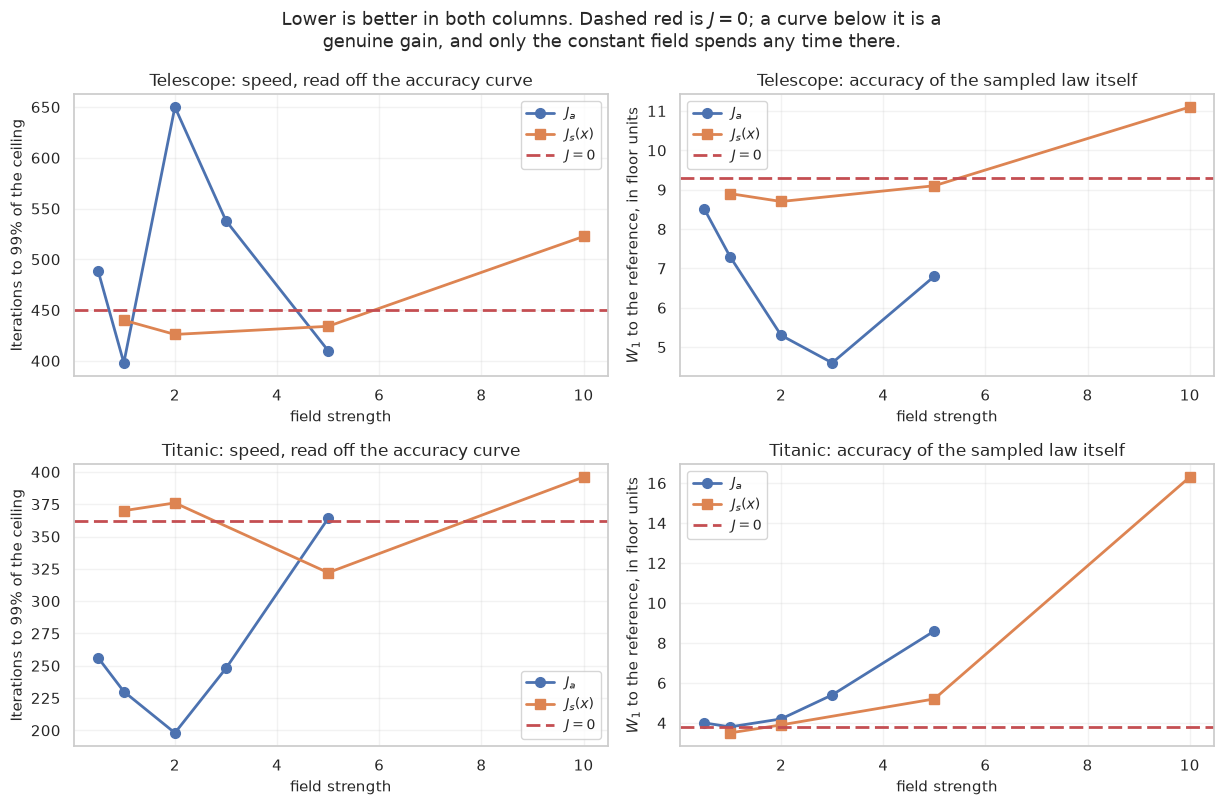

In [10]:
LABELS = ["$J_a$", "$J_s(x)$"]
MARK = {"$J_a$": "o", "$J_s(x)$": "s"}

fig, axes = plt.subplots(2, 2, figsize=(12.4, 8.2))
for r, k in enumerate(SETUP):
    z = SWEEP[SWEEP.dataset == k]
    for c, (ylab, ttl) in enumerate(((
            "Iterations to 99% of the ceiling", "speed, read off the accuracy curve"),
            ("$W_1$ to the reference, in floor units", "accuracy of the sampled law itself"))):
        ax = axes[r, c]
        for lab in LABELS:
            zz = z[z.field == lab.replace("$", "")].sort_values("strength")
            xs = zz["strength"].values
            ys = ([np.nanmean(SW[(k, lab, float(s))][1]) for s in xs] if c == 0
                  else zz["W1 / floor"].values)
            ax.plot(xs, ys, MARK[lab] + "-", color=COLORS[lab], linewidth=2.0,
                    markersize=7, label=lab)
        y0 = (np.nanmean(SW[(k, "$J = 0$", 0.0)][1]) if c == 0
              else float(z[z.field == "J = 0"]["W1 / floor"].iloc[0]))
        ax.axhline(y0, color=COLORS["$J = 0$"], linestyle=(0, (5, 2)), linewidth=2.0,
                   label="$J = 0$")
        ax.set_xlabel("field strength", fontsize=11)
        ax.set_ylabel(ylab, fontsize=11)
        ax.set_title("{}: {}".format(k, ttl), fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(alpha=0.25)
fig.suptitle("Lower is better in both columns. Dashed red is $J = 0$; a curve below it is a\n"
             "genuine gain, and only the constant field spends any time there.", fontsize=13)
plt.tight_layout()
plt.savefig("figures/nald_sweep.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Why

The separation is not about tuning. It is the kernel.

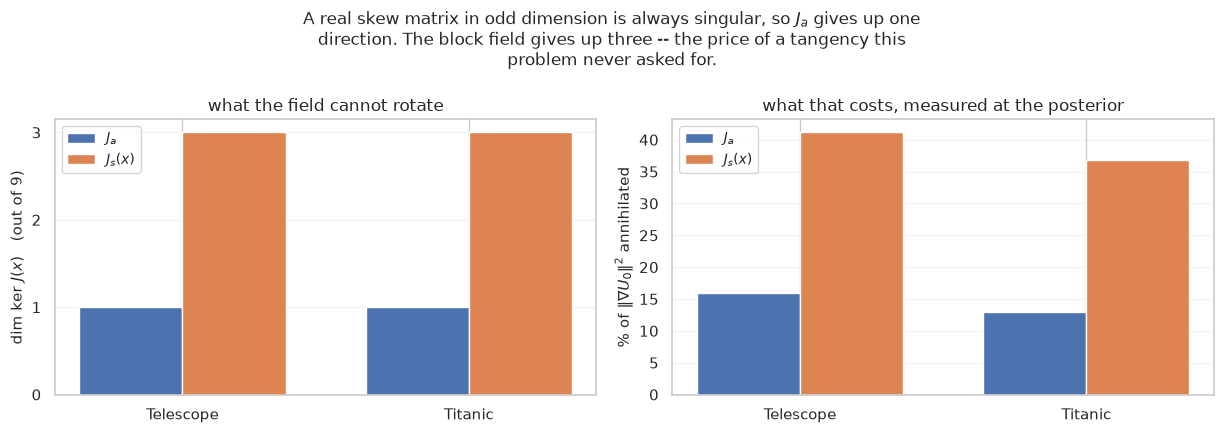

In [11]:
# Where it costs: the share of the drift lying in the kernel, at the posterior itself
share = {k: {lab: annihilated_share(f, torch.tensor(DATA[k]["ref"][:300]),
                                    DATA[k]["target"].anchored(
                                        torch.tensor(DATA[k]["ref"][:300]))[1])
             for lab, f in FIELDS.items()} for k in SETUP}

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4))
ks = list(SETUP)
x = np.arange(len(ks))
wd = 0.36
for lab, off in ((("$J_a$"), -wd / 2), (("$J_s(x)$"), wd / 2)):
    axes[0].bar(x + off, [float(REP.loc[lab.replace("$", ""), "dim_ker"])] * len(ks), wd,
                color=COLORS[lab], label=lab)
    axes[1].bar(x + off, [100 * share[k][lab] for k in ks], wd,
                color=COLORS[lab], label=lab)
for ax, ylab, ttl in ((axes[0], "dim ker $J(x)$   (out of 9)", "what the field cannot rotate"),
                      (axes[1], "% of $\\|\\nabla U_0\\|^2$ annihilated",
                       "what that costs, measured at the posterior")):
    ax.set_xticks(x)
    ax.set_xticklabels(ks)
    ax.set_ylabel(ylab, fontsize=11)
    ax.set_title(ttl, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.25, axis="y")
axes[0].set_yticks([0, 1, 2, 3])
fig.suptitle("A real skew matrix in odd dimension is always singular, so $J_a$ gives up one\n"
             "direction. The block field gives up three -- the price of a tangency this\n"
             "problem never asked for.", fontsize=12)
plt.tight_layout()
plt.savefig("figures/nald_kernel.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Summary

**Without the wall, the verdict reverses.** Under a ball constraint the block field
$J_s(x)$ wins and the constant $J_a$ is not even admissible. Under the unconstrained
dynamics both are admissible, and it is $J_a$ that helps.

Speed, as iterations for the mean training accuracy to reach 99% of the exact posterior's,
5 replicas of 100 walkers with bootstrap intervals:

| | $J=0$ | best $J_a$ | best $J_s(x)$ |
|---|---|---|---|
| Telescope | 450 [424, 470] | **398 [362, 426]**, $1.13\times$ [1.03, 1.26] at $a=1$ | 426 [408, 444], $1.06\times$ [0.98, 1.13] at $s=2$ |
| Titanic | 362 [336, 390] | **198 [182, 216]**, $1.83\times$ [1.62, 2.04] at $a=2$ | 322 [280, 362], $1.12\times$ [0.98, 1.32] at $s=5$ |

Every $J_s(x)$ interval contains 1. Across both datasets and all four strengths it was
tried at, the block field never produced a speed-up that survives its own error bars.
$J_a$ does, on both.

The same ordering holds for the sampled law, which is the metric accuracy cannot see.
$W_1$ to the reference, in units of the floor two converged samples of this size cost each
other:

| | $J=0$ | best $J_a$ | best $J_s(x)$ |
|---|---|---|---|
| Telescope | $9.3\times$ | **$4.6\times$** at $a=3$ | $8.7\times$ at $s=2$ |
| Titanic | $3.8\times$ | $3.8\times$ at $a=1$ | $3.5\times$ at $s=1$ |

On the Telescope data $J_a$ halves the distance to the posterior. $J_s(x)$ moves it by
nothing worth reporting on either table.

**The mechanism is the kernel, not the tuning.** A real skew matrix in odd dimension is
always singular, so $J_a$ carries a one-dimensional kernel. The block field carries three,
one per $3\times3$ block, and at the posterior that subspace holds

| | $J_a$ | $J_s(x)$ |
|---|---|---|
| Telescope | 15.9% of $\|\nabla U_0\|^2$ | **41.1%** |
| Titanic | 12.9% | **36.8%** |

Two fifths of the drift is invisible to the field that is supposed to rotate it. On a
centred ball that same kernel is precisely the tangency $J_s(x)x=0$ that makes the field
admissible at the wall, which is why it wins there. The theory says this in one line: the
construction *"annihilates a radial $\nabla U_0$; the constant-$J$ Student construction and
the more general stream choice therefore remain essential."* These numbers are that
sentence priced on two datasets.

**Strengths do not transfer.** Run at the values the constrained study used, $J_a$ at
$a=2$ on the Telescope data is $0.69\times$ [0.65, 0.74] — materially *slower* than
$J=0$ — while cutting $W_1$ from $9.3$ to $5.3$ floor units. Speed and fidelity disagree
about that setting, and a paper-style accuracy figure alone would have called it a
regression. Anything tuned against a wall has to be re-swept once the wall is gone.

**What this does not show.** Accuracy reads only $\operatorname{sign}\langle
w,\phi\rangle$ and is invariant under $w\mapsto cw$, so the top row of each figure is a
weak instrument by construction; the $W_1$ columns carry the real evidence, and they rest
on a random-walk Metropolis reference whose proposal is adapted to 25% acceptance rather
than on an exact draw. The comparison is also specific to this potential: an isotropic
Gaussian prior puts a large radial component in $\nabla U_0$, which is the component the
block field discards. A posterior whose drift lives mostly inside the blocks would not be
penalised the same way.